## 探討地震對建築物破壞程度影響
**第六組**



## 目錄
1. 環境準備
2. 資料預覽與數據清洗
3. 字串編號化與平滑處理
4. 特徵分析工程
5. 模型前處理與預測
6. 預測重要度比較
7. 重要特徵分析
8. 特徵重要度與相關係數比較


## 1. 環境準備
* Numpy: 數值運算
* Pandas: Dataframe 處理
* Matplotlib: 數據視覺化
* Seaborn: 數據視覺化
* Sklearn: 機器學習
* Math: 基本數學符號

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score 
from sklearn.preprocessing import LabelEncoder
# 數據引入 (記得放入同個資料夾)
df = pd.read_csv("csv_building_structure.csv", index_col = 'building_id')

## 2. 資料預覽與資料清洗

In [3]:
# 資料預覽
print("Structure data has {} rows and {} columns".format(*df.shape))

display(df.dtypes.value_counts())
df.dtypes

Structure data has 762106 rows and 30 columns


int64     20
object    10
dtype: int64

district_id                                int64
vdcmun_id                                  int64
ward_id                                    int64
count_floors_pre_eq                        int64
count_floors_post_eq                       int64
age_building                               int64
plinth_area_sq_ft                          int64
height_ft_pre_eq                           int64
height_ft_post_eq                          int64
land_surface_condition                    object
foundation_type                           object
roof_type                                 object
ground_floor_type                         object
other_floor_type                          object
position                                  object
plan_configuration                        object
has_superstructure_adobe_mud               int64
has_superstructure_mud_mortar_stone        int64
has_superstructure_stone_flag              int64
has_superstructure_cement_mortar_stone     int64
has_superstructure_m

### 資料清洗
- 檢查缺失值
- 直接刪除缺失值，因為資料數夠多

In [4]:
# 資料清洗
# 檢查缺失值
df_temp = df.isnull().sum().reset_index(name = 'count')
display(df_temp[df_temp['count'] > 0])

# 刪除缺失值欄位(有76萬筆資料，數量夠多可直接刪除)
df.dropna(inplace = True)

,index,count
14,position,1
15,plan_configuration,1
28,damage_grade,12
29,technical_solution_proposed,12


## 3. 字串編號化與平滑處理
### 3.1 受損等級分佈
首先，我們的應變變因是「建築物受損程度」，在資料中找到「Grade」，所以我們先分析其在資料中的分布情形。


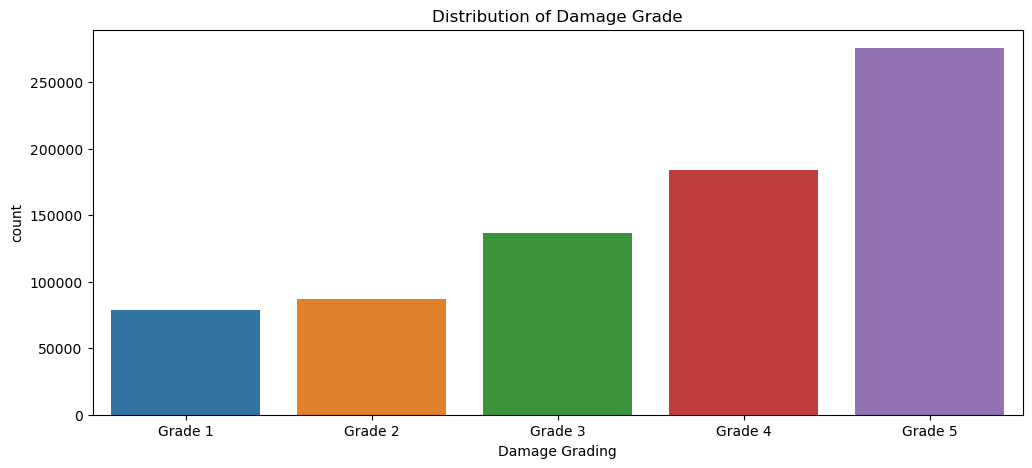

In [5]:
plt.figure(figsize = (12, 5))
ax = sns.countplot(x = 'damage_grade', data = df, order = ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5'])
plt.title("Distribution of Damage Grade")
plt.xlabel("Damage Grading")
plt.show()

### 3.2 字串編碼與平滑處理

處理像 `ward_id`（地區）這種有成千上萬種分類的資料，如果用舊方法硬拆成幾千個欄位，資料表會太寬導致電腦跑很慢。

- **encode 編碼**：
 使帶有字串的資料先轉換成數字(n種資料就轉換成0 ~ n-1整數)，

- **平滑處理**：
   把轉換過的數字使用 **受損等級** 做加權，讓不連續的整數變成 **「平均倒塌風險分數」** 而變成連續平滑數據。這樣能讓模型看到數字，就能直接知道這裡有多危險。

In [6]:
# 定義平滑目標編碼函數
def smooth_mean_encoding(df, by, on, m = 5):
    mean = df[on].mean() # 基於 grade 做平滑性
    agg = df.groupby(by)[on].agg(['count', 'mean'])
    counts = agg['count']   # 類別數量
    means = agg['mean']     # 數值化平均
    smooth = (counts * means + m * mean) / (counts + m)  # m當編碼化的權的加權平均
    return df[by].map(smooth).fillna(mean)

le = LabelEncoder()
df['damage_grade_encoded'] = le.fit_transform(df['damage_grade'])
categorical_cols = [
    'vdcmun_id', 'ward_id',
    'land_surface_condition', 'foundation_type', 'roof_type', 
    'ground_floor_type', 'other_floor_type', 
    'position', 'plan_configuration'
]

for col in categorical_cols:
    if col in df.columns:
        df[f'{col}_encoded'] = smooth_mean_encoding(df, by = col, on = 'damage_grade_encoded')

print("字串編號化與平滑處理完成")


字串編號化與平滑處理完成


## 4. 特徵分析工程
### 4.1 特徵相關係數分析

一次把所有類型的特徵與受損等級做比對，觀察是誰主要影響受損的主要變因。

- 相關係數越高，房子越容易倒。
- 相關係數越低，房子越穩固。

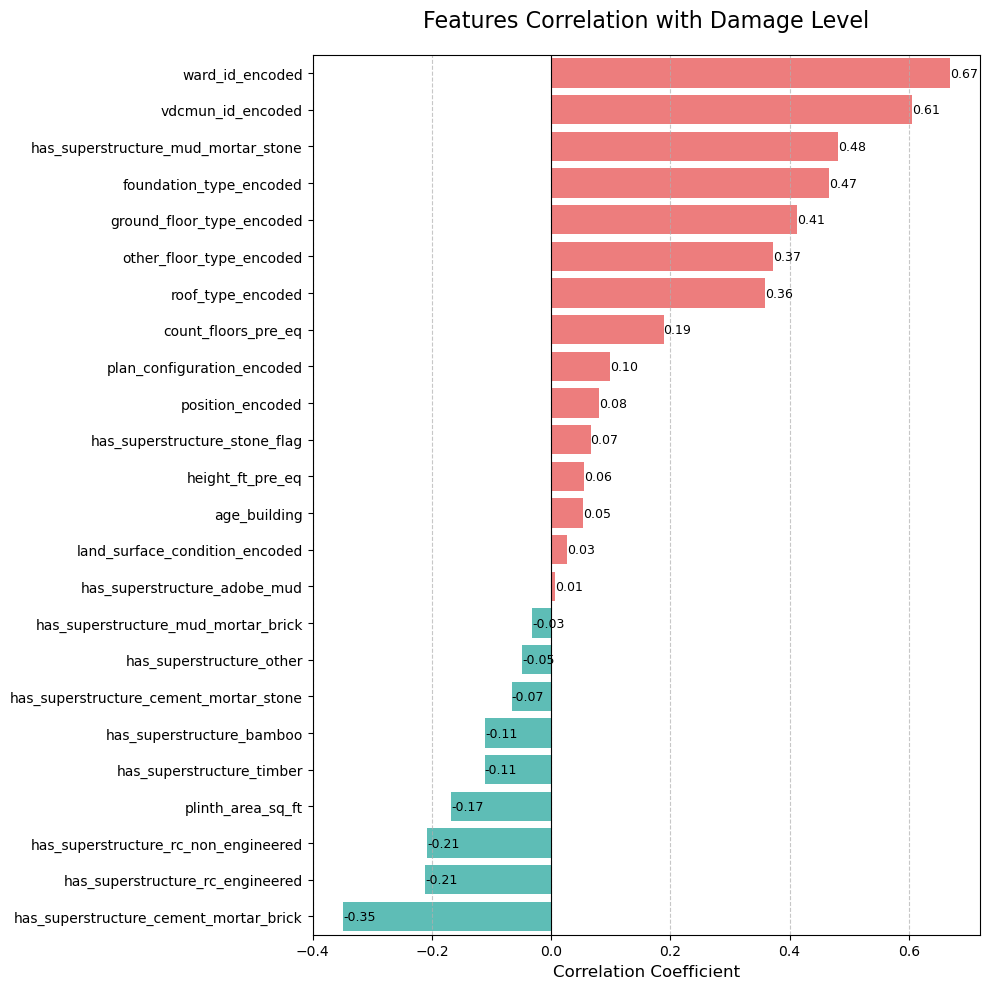

In [7]:
# 定義所有特徵清單
encoded_cols = [
    'vdcmun_id_encoded', 'ward_id_encoded',
    'land_surface_condition_encoded', 'foundation_type_encoded',
    'roof_type_encoded', 'ground_floor_type_encoded',
    'other_floor_type_encoded', 'position_encoded',
    'plan_configuration_encoded'
]

material_cols = [
    'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
    'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone',
    'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick',
    'has_superstructure_timber', 'has_superstructure_bamboo',
    'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered',
    'has_superstructure_other'
]

basic_cols = ['count_floors_pre_eq', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq']

# 合併並計算相關係數
all_features = encoded_cols + material_cols + basic_cols
analysis_df = df[all_features].copy()
analysis_df['Damage Level'] = df['damage_grade_encoded']

# 計算相關係數並排序
corr_data = analysis_df.corr()['Damage Level'].drop('Damage Level')
corr_data = corr_data.sort_values(ascending = False)

# 繪製水平長條圖
plt.figure(figsize = (10, 10)) 

# 設定顏色
colors = ['#ff6b6b' if x > 0 else '#4ecdc4' for x in corr_data.values]

# 畫圖
sns.barplot(x = corr_data.values, y = corr_data.index, palette = colors)

# 文字與標示
plt.title('Features Correlation with Damage Level', fontsize = 16, pad = 20)
plt.xlabel('Correlation Coefficient', fontsize = 12)
plt.axvline(x = 0, color = 'black', linestyle = '-', linewidth = 0.8) # 中間基準線
plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
for i, v in enumerate(corr_data.values):
    plt.text(v, i, f'{v:.2f}', va='center', fontsize = 9)

plt.tight_layout()
plt.show()

### 4.2 計算物理特徵

不只使用原始模型，透過物理公式組合現有欄位，計算出預測能力更強的指標。

- **幾何結構**：計算體積與細長比。理論上，又細又高的房子地震時搖晃更劇烈更容易倒。
- **脆弱與穩定分數**：把「脆弱材質」與「穩定材質」分別加總。分數越高，代表結構越脆弱/穩定。
- **危險加成**：計算高度 x 脆弱度。計算出蓋得很高，卻用很爛的材料的物理特徵。以及屋齡 x 是否使用泥漿石，計算出又老又是泥漿做的物理特徵

In [ ]:
# 體積
df['volume'] = df['plinth_area_sq_ft'] * df['height_ft_pre_eq']
# 細長比
df['slenderness'] = df['height_ft_pre_eq'] / (np.sqrt(df['plinth_area_sq_ft']))

df['age_x_mud'] = df['age_building'] * df['has_superstructure_mud_mortar_stone']
# 每層樓高度
df['height_per_floor'] = df['height_ft_pre_eq'] / df['count_floors_pre_eq']

# 是否使用脆弱材料
weak_materials = [
    'has_superstructure_mud_mortar_stone',
    'has_superstructure_adobe_mud',
    'has_superstructure_stone_flag',
    'has_superstructure_mud_mortar_brick'
]
df['weakness_score'] = df[weak_materials].sum(axis = 1)

# 使用脆弱材料的危險高度
df['height_x_weakness'] = df['height_ft_pre_eq'] * df['weakness_score']

# 是否使用穩定材料
strong_materials = [
    'has_superstructure_cement_mortar_brick',
    'has_superstructure_rc_engineered',
    'has_superstructure_rc_non_engineered'
]
df['strength_score'] = df[strong_materials].sum(axis = 1)
print("物理特徵計算完成")

物理特徵計算完成


### 4.3 物理特徵與受損等級之關聯分析 

驗證我們透過特徵工程所創造出的「物理特徵」（如脆弱度分數、細長比、危險高度等），是否確實與建築物的受損等級存在顯著的線性關聯。

- 比較係數越高，代表該特徵與「建築倒塌」有正向關聯。像 `weakness_score` 與 `height_x_weakness` 呈現正相關。
- 比較係數越低，代表該特徵有助於「建築安全」。像 `strength_score` 呈現負相關。

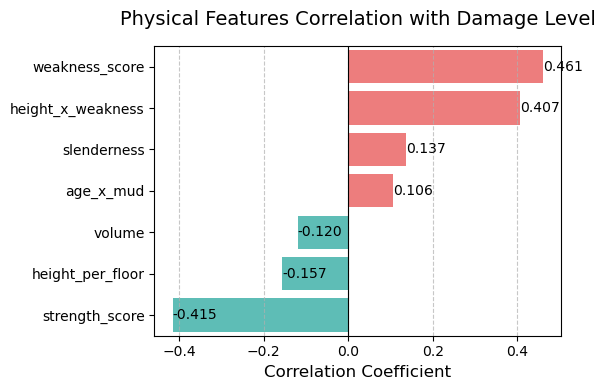

In [21]:
physics_features = [
    'volume', 
    'slenderness', 
    'age_x_mud', 
    'height_per_floor', 
    'weakness_score',
    'height_x_weakness', 
    'strength_score'
]

# 計算相關係數
physics_df = df[physics_features].copy()
physics_df['Damage Level'] = df['damage_grade_encoded']

corr_physics = physics_df.corr()['Damage Level'].drop('Damage Level')
corr_physics = corr_physics.sort_values(ascending = False)

# 繪製水平長條圖
plt.figure(figsize = (6, 4)) 

colors = ['#ff6b6b' if x > 0 else '#4ecdc4' for x in corr_physics.values]

sns.barplot(x = corr_physics.values, y = corr_physics.index, palette = colors)

plt.title('Physical Features Correlation with Damage Level', fontsize = 14, pad = 15)
plt.xlabel('Correlation Coefficient', fontsize = 12)
plt.axvline(x = 0, color = 'black', linestyle = '-', linewidth = 0.8)
plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)

# 標上數值
for i, v in enumerate(corr_physics.values):
    plt.text(v, i, f'{v:.3f}', va = 'center', fontsize=10)

plt.tight_layout()
plt.show()

## 5. 模型前處理與預測
### 5.1 資料前處理

為了提升模型的預測實用性與準確度，我們將原始的 5 個受損等級依據「修復成本」與「結構安全性」合併為 3 大類。

**合併策略**：
- **Level 0 (Safe)**：對應 **Grade 1**。建築完好或輕微受損，無需重大修復。
- **Level 1 (Repair)**：對應 **Grade 2 & 3**。結構受損但未倒塌，需進行加固或修復。
- **Level 2 (Rebuild)**：對應 **Grade 4 & 5**。建築嚴重受損或全倒，需拆除重建。

這能有效減少相鄰等級間的模糊地帶，讓模型專注於區分「安全」、「需修復」與「危險」三種關鍵狀態。

In [ ]:
# 標籤合併 (5類變3類)
raw_y = df['damage_grade_encoded']

def merge_grades(val):
    if val <= 0: return 0      # Low (Grade 1)
    elif val <= 2: return 1    # Mid (Grade 2 & 3)
    else: return 2             # High (Grade 4 & 5)

y = raw_y.apply(merge_grades)

features = [
    # 編碼後特徵
    'vdcmun_id_encoded', 'ward_id_encoded',
    'land_surface_condition_encoded', 'foundation_type_encoded',
    'roof_type_encoded', 'ground_floor_type_encoded',
    'other_floor_type_encoded', 'position_encoded',
    'plan_configuration_encoded',
    
    # 原始數值
    'count_floors_pre_eq', 'age_building',
    'plinth_area_sq_ft', 'height_ft_pre_eq',
    
    # 物理特徵
    'volume', 'slenderness', 'age_x_mud', 
    'height_per_floor', 'weakness_score','height_x_weakness', 'strength_score',

    'has_superstructure_mud_mortar_stone',
    'has_superstructure_rc_engineered',
    'has_superstructure_mud_mortar_brick'
]
X = df[features]
print('預測前處理完成')

23
預測前處理完成


### 5.2 模型訓練

將資料切分為訓練集與測試集，並設定隨機森林模型，並開始訓練。

**隨機森林 (Random Forest Classifier)**：
- 選用 Random Forest 是因為它對「非線性特徵」有不錯的能力。
- 能有效處理我們特徵工程中產生的各類數值與比例特徵。

最後依照準確度分數進行模型優化與特徵更改

In [30]:
# 切分訓練資料
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

# 2. 定義RF模型 
clf = RandomForestClassifier(
    n_estimators = 100,
    min_samples_leaf = 3,
    random_state = 42,
    class_weight = 'balanced',
    n_jobs = -1, # 全CPU啟用
)

# 3. 訓練
print("訓練中稍等一下...約1分半左右")
clf.fit(X_train, y_train)

# 預測
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"準確率 : {accuracy:.4f}")

# 顯示詳細報告
target_names = ['Level 1 (Low)', 'Level 2 (Mid)', 'Level 3 (High)']
print("\n分類報告:")
print(classification_report(y_test, y_pred, target_names = target_names))

訓練中稍等一下...約1分半左右
準確率 : 0.7451

分類報告:
                precision    recall  f1-score   support

 Level 1 (Low)       0.59      0.76      0.66     15763
 Level 2 (Mid)       0.59      0.62      0.60     44734
Level 3 (High)       0.87      0.80      0.84     91922

      accuracy                           0.75    152419
     macro avg       0.68      0.73      0.70    152419
  weighted avg       0.76      0.75      0.75    152419



## 6. 預測重要度比較

視覺化 Random Forest 模型在預測房屋受損時，最依賴哪些特徵進行決策。

- 排名越靠前的特徵（如 `ward_id_encoded` 或 `age_building`），代表其提供的資訊含量越高。
- 接下來會詳細討論排名較高的幾個特徵其分布情形。

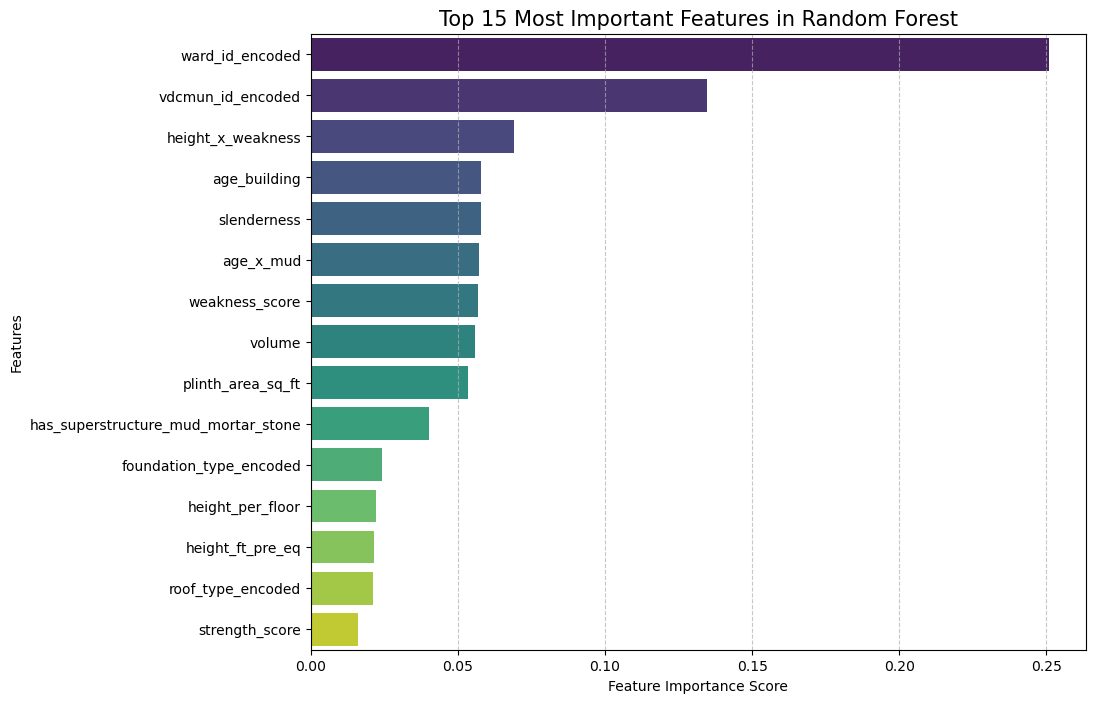

In [24]:
importances = clf.feature_importances_
feature_names = X.columns 

# 整理成 DataFrame 並排序
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by = 'Importance', ascending = False).head(15) 

# 繪圖
plt.figure(figsize = (10, 8))
sns.barplot(x = 'Importance', y = 'Feature', data = feature_imp_df, palette = 'viridis')

plt.title('Top 15 Most Important Features in Random Forest', fontsize = 15)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
plt.show()

## 7. 重要特徵分析

針對模型認為最重要的三大面向：**地點 (Ward ID)**、**使用脆弱材料的每層高度 (Height x Weakness)** 與 **屋齡 (Age)**，詳細分析其在 Grade 1 到 Grade 5 的變化趨勢。

- **左圖 (Violin Plot)**：觀察資料分佈的密度。若 Grade 5 的波峰明顯高於 Grade 1，代表該特徵能有效區分危險群體。
- **右圖 (Point Plot)**：觀察平均風險趨勢。

稍等一下這要跑一段時間...約50秒


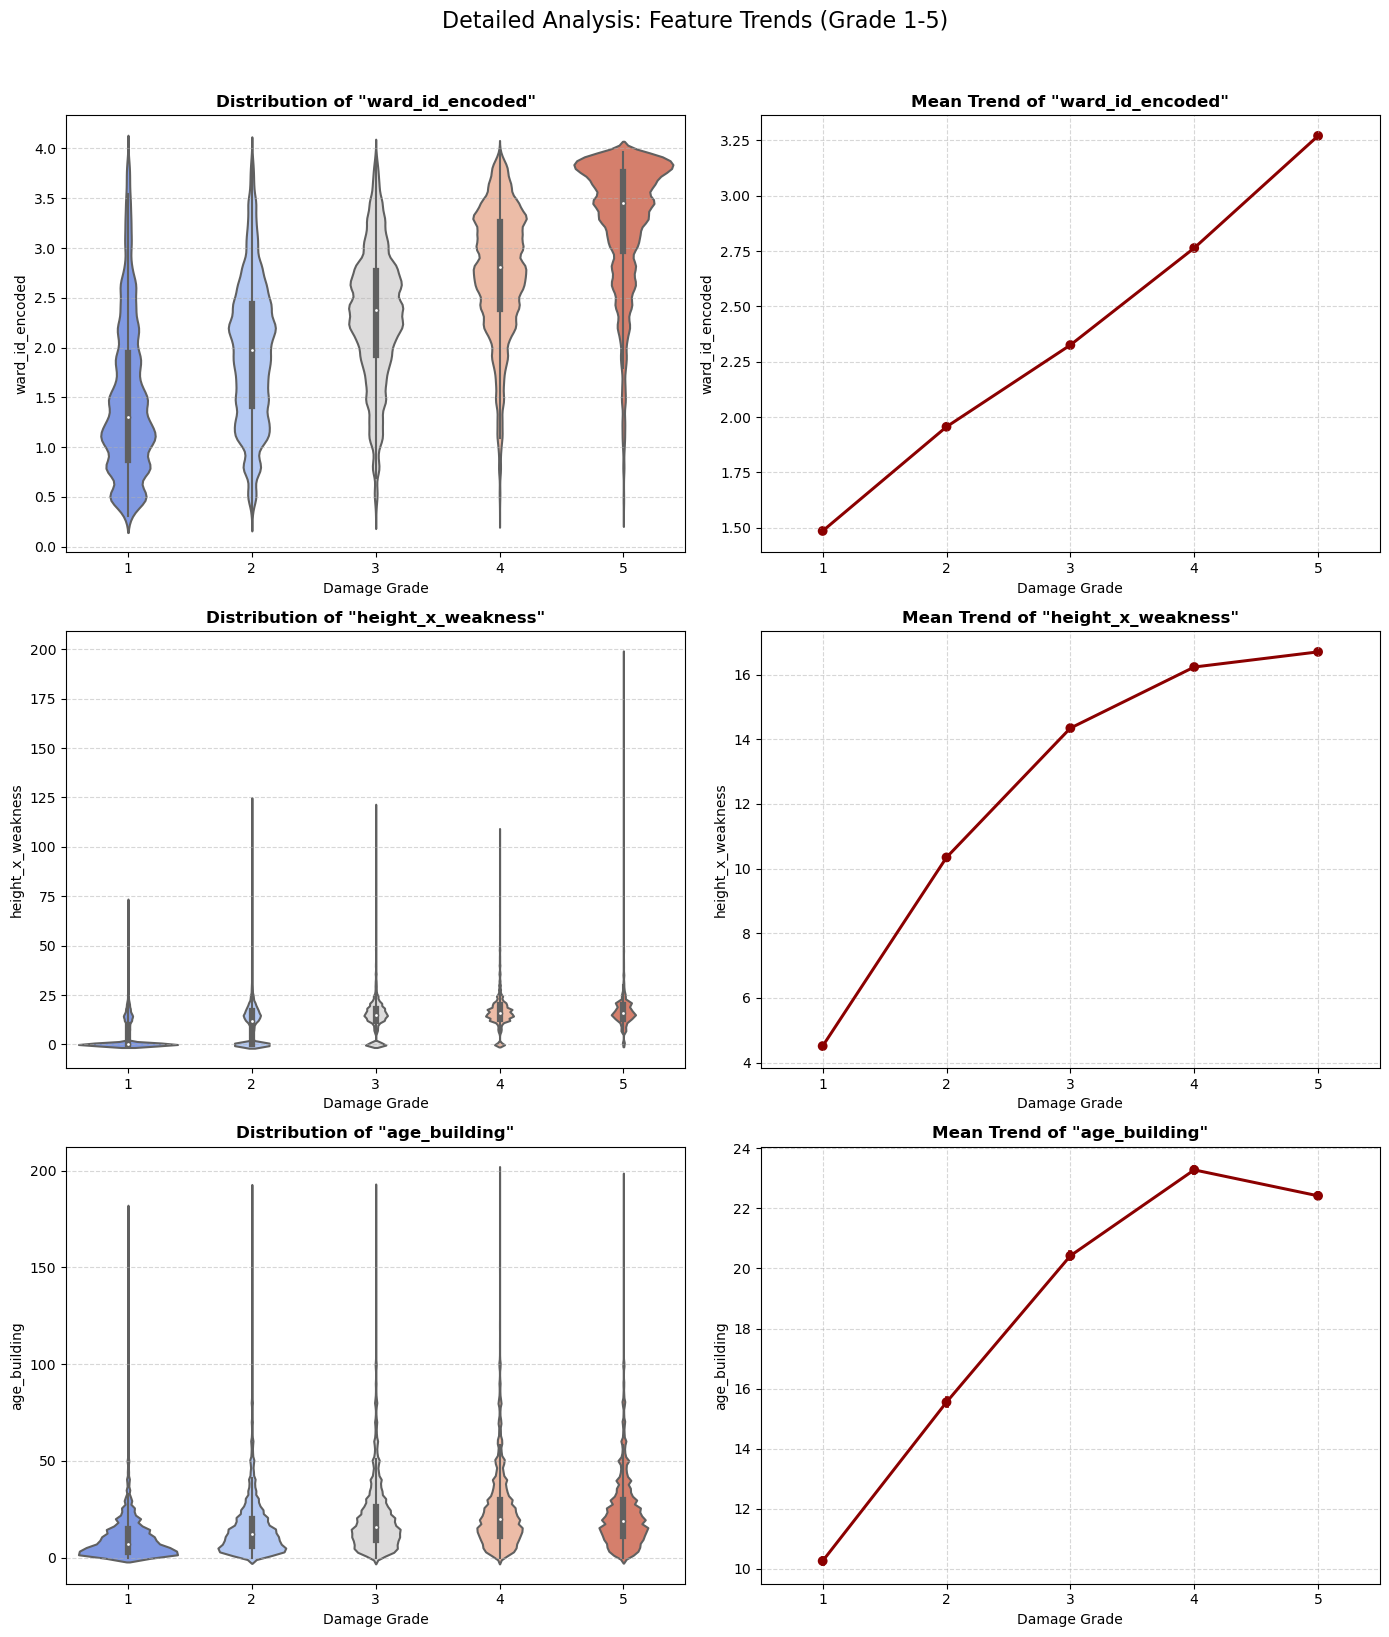

In [ ]:
plot_data = df.copy()
target_col = 'damage_grade_encoded'
grade_order = [0, 1, 2, 3, 4]

# 過濾屋齡 
if 'age_building' in plot_data.columns:
    plot_data = plot_data[plot_data['age_building'] < 200]

# 重要度高的特徵
features = ['ward_id_encoded', 'height_x_weakness', 'age_building']

# 繪圖 小提琴圖遇折線圖
fig, axes = plt.subplots(3, 2, figsize = (14, 16))
palette = sns.color_palette('coolwarm', n_colors = 5)
print('稍等一下這要跑一段時間...約50秒')

for i, feature in enumerate(features):

    # 左圖：小提琴圖 
    sns.violinplot(
        x = target_col, 
        y = feature, 
        data = plot_data, 
        ax = axes[i, 0], 
        palette = palette,
        order = grade_order
    )
    axes[i, 0].set_title(f'Distribution of "{feature}"', fontsize=12, fontweight='bold')
    axes[i, 0].grid(axis='y', linestyle='--', alpha=0.5)
    
    axes[i, 0].set_xticklabels(['1', '2', '3', '4', '5'])
    axes[i, 0].set_xlabel('Damage Grade') 

    # 右圖：折線圖
    sns.pointplot(
        x = target_col, 
        y = feature, 
        data = plot_data, 
        ax = axes[i, 1],
        color = 'darkred',
        scale = 0.8,
        errorbar = ('ci', 99),
        order = grade_order
    )
    axes[i, 1].set_title(f'Mean Trend of "{feature}"', fontsize = 12, fontweight = 'bold')
    axes[i, 1].grid(True, linestyle = '--', alpha = 0.5)

    axes[i, 1].set_xticklabels(['1', '2', '3', '4', '5'])
    axes[i, 1].set_xlabel('Damage Grade')

plt.suptitle('Detailed Analysis: Feature Trends (Grade 1-5)', fontsize = 16, y = 1.02)
plt.tight_layout()

plt.show()

## 8. 特徵重要度與相關係數比較

比較「相關係數 (線性關係)」與「特徵重要性 (非線性關係)」的差異，解釋使用隨機森林的原因。

- **右上/右下**：既重要又高度相關（如 `weakness_score`），是最穩定的預測變因。
- **右側中間**：相關係數低但模型認為重要（如 `age_building`）。這代表該特徵與結果存在「非線性關係」，這正是選擇隨機森林而不是線性回歸的原因。

C:\Users\sam08\AppData\Local\Temp\ipykernel_7868\2271720087.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


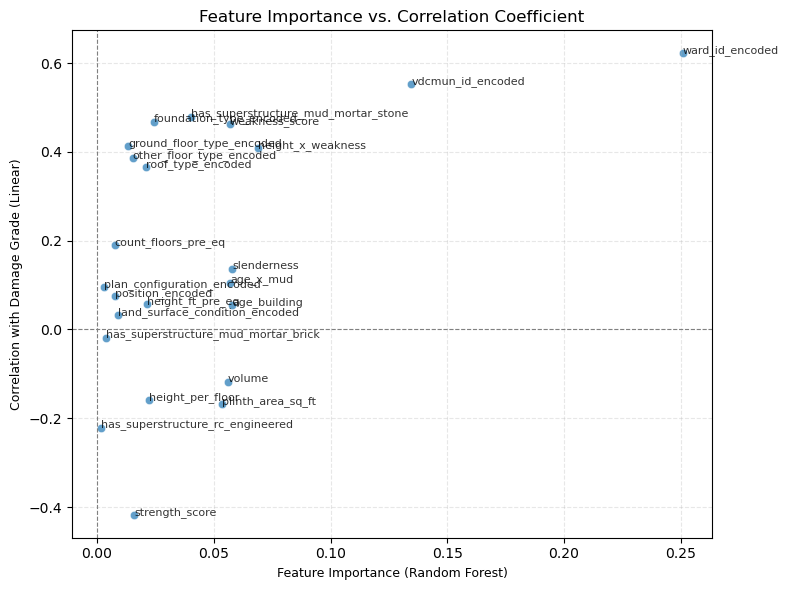

In [ ]:
importances = clf.feature_importances_
feature_names = X_train.columns

# 取得相關係數
if hasattr(y_train, 'values'):
    target = y_train.values
else:
    target = y_train

# 計算每個特徵與 Target 的相關係數
correlations = []
for col in feature_names:
    corr = np.corrcoef(X_train[col], target)[0, 1]
    correlations.append(corr)

# 合併成一個 DataFrame
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Correlation': correlations,
    'Abs_Correlation': np.abs(correlations) # 取絕對值方便比較大小
})

# 2. 繪製散佈圖
plt.figure(figsize = (8, 6))
sns.scatterplot(
    data=comparison_df, 
    x = 'Importance', 
    y = 'Correlation', 
    sizes = (50, 400),
    alpha = 0.7,
    palette = 'coolwarm'
)

# 畫出十字
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# 標示重點特徵 
top_important = comparison_df.nlargest(5, 'Importance')     # 找出重要性5個
top_correlated = comparison_df.nlargest(3, 'Abs_Correlation')   # 找出相關性3個

# 合併標籤名單
labels_to_show = pd.concat([top_important, top_correlated])

# 加上文字標籤
texts = []
for i, row in comparison_df.iterrows():
    texts.append(plt.text(
        row['Importance'], 
        row['Correlation'], 
        row['Feature'], 
        fontsize = 8,       
        color = 'black',    
        alpha = 0.8   
    ))

# 文字說明
plt.title('Feature Importance vs. Correlation Coefficient', fontsize = 12)
plt.xlabel('Feature Importance (Random Forest)', fontsize = 9)
plt.ylabel('Correlation with Damage Grade (Linear)', fontsize = 9)

plt.grid(True, linestyle='--', alpha = 0.3)
plt.tight_layout()
plt.show()